In [1]:
# ============================================================
# SMART ENERGY GRID LOAD FORECASTING
# PART 1 - IMPORTS & FEATURE ENGINEERING
# ============================================================

# Install LightGBM
!pip -q install lightgbm

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from lightgbm import LGBMRegressor
from google.colab import files

print("="*60)
print("UPLOAD PJME_hourly.csv")
print("="*60)

uploaded = files.upload()

filename = list(uploaded.keys())[0]

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv(filename)

# Rename columns if required
if "Datetime" not in df.columns:
    df.columns = ["Datetime","PJME_MW"]

# Convert datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Sort data
df = df.sort_values("Datetime")

# Set datetime index
df.set_index("Datetime", inplace=True)

print("\nDataset Loaded Successfully")
print(df.head())

# ------------------------------------------------------------
# FEATURE ENGINEERING
# ------------------------------------------------------------

df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month
df["year"] = df.index.year
df["weekday"] = df.index.weekday

df["dayofyear"] = df.index.dayofyear

df["weekofyear"] = df.index.isocalendar().week.astype(int)

df["is_weekend"] = (df.index.weekday >= 5).astype(int)

# ------------------------------------------------------------
# CYCLICAL FEATURES
# ------------------------------------------------------------

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)

df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)

df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

print("\nFeature Engineering Completed")
print(df.head())

UPLOAD PJME_hourly.csv


Saving PJME_hourly.csv to PJME_hourly.csv

Dataset Loaded Successfully
                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0

Feature Engineering Completed
                     PJME_MW  hour  day  month  year  weekday  dayofyear  \
Datetime                                                                   
2002-01-01 01:00:00  30393.0     1    1      1  2002        1          1   
2002-01-01 02:00:00  29265.0     2    1      1  2002        1          1   
2002-01-01 03:00:00  28357.0     3    1      1  2002        1          1   
2002-01-01 04:00:00  27899.0     4    1      1  2002        1          1   
2002-01-01 05:00:00  28057.0     5    1      1  2002        1          1   

                     weekofyear  is_weekend  hour_sin  hour_cos  month_sin  \
Datetime                                                                     
2002-0

In [2]:
# ============================================================
# PART 2 - MODEL TRAINING
# ============================================================

# Features used for training
FEATURES = [
    "hour",
    "day",
    "month",
    "year",
    "weekday",
    "dayofyear",
    "weekofyear",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos"
]

TARGET = "PJME_MW"

X = df[FEATURES]
y = df[TARGET]

# ------------------------------------------------------------
# Train-Test Split (80% Train, 20% Test)
# ------------------------------------------------------------

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("=" * 60)
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("=" * 60)

# ------------------------------------------------------------
# Build LightGBM Model
# ------------------------------------------------------------

model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("\nTraining model...\n")

model.fit(X_train, y_train)

print("✅ Model training completed successfully!")

# ------------------------------------------------------------
# Predict on Test Data
# ------------------------------------------------------------

predictions = model.predict(X_test)

print("\nFirst 10 Predictions:")

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": predictions[:10]
})

print(comparison)

Training Samples : 116292
Testing Samples  : 29074

Training model...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 464
[LightGBM] [Info] Number of data points in the train set: 116292, number of used features: 12
[LightGBM] [Info] Start training from score 32328.165695
✅ Model training completed successfully!

First 10 Predictions:
    Actual     Predicted
0  32204.0  30276.765359
1  32049.0  29872.844488
2  32209.0  29719.568068
3  32707.0  29832.376022
4  33012.0  30032.857010
5  33843.0  30333.269528
6  33755.0  30898.318503
7  32363.0  30308.515812
8  30060.0  28302.060671
9  27846.0  26071.077323



MODEL EVALUATION
Mean Absolute Error (MAE) : 3135.98 MW
Root Mean Squared Error   : 4180.54 MW
R² Score                  : 0.5849
Approximate Accuracy      : 90.06%

✅ Model saved successfully as:
smart_grid_future.pkl

Feature Importance:
       Feature  Importance
5    dayofyear        9242
3         year        7946
1          day        7067
4      weekday        4022
6   weekofyear        3053
0         hour        2814
2        month        1354
11   month_cos        1138
10   month_sin        1110
8     hour_sin         775
9     hour_cos         442
7   is_weekend         237


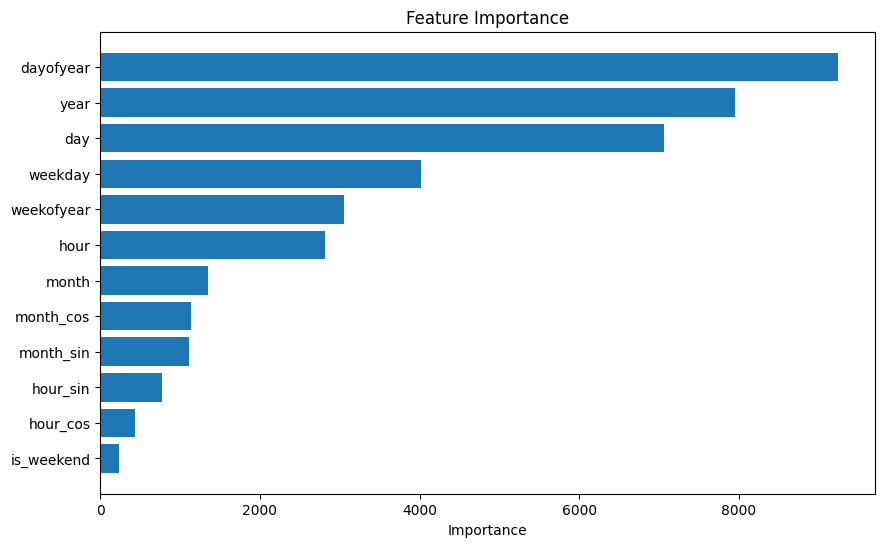

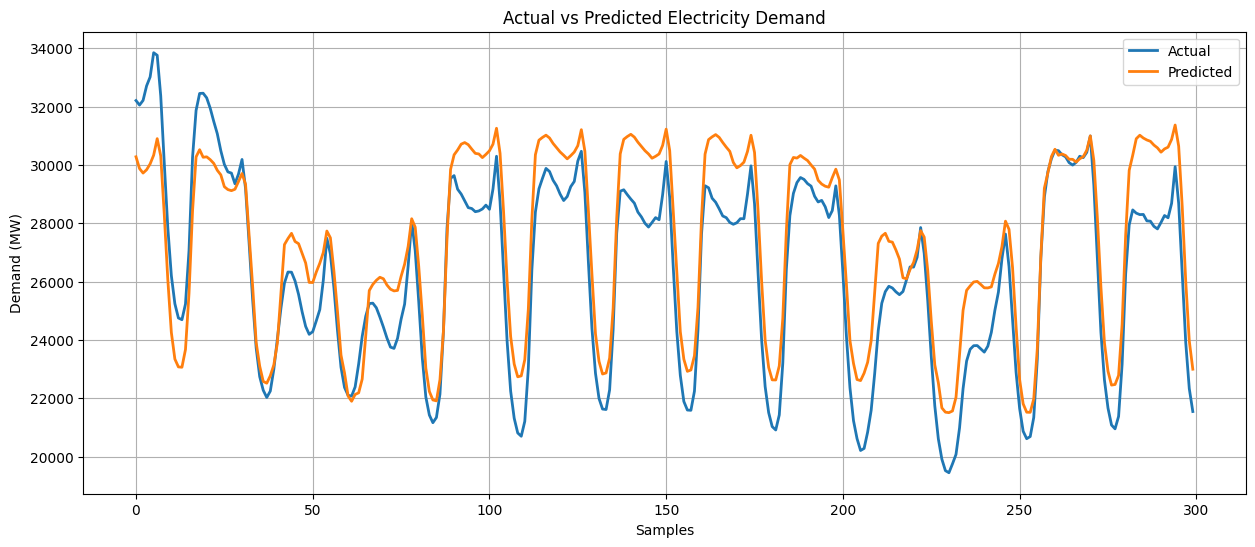

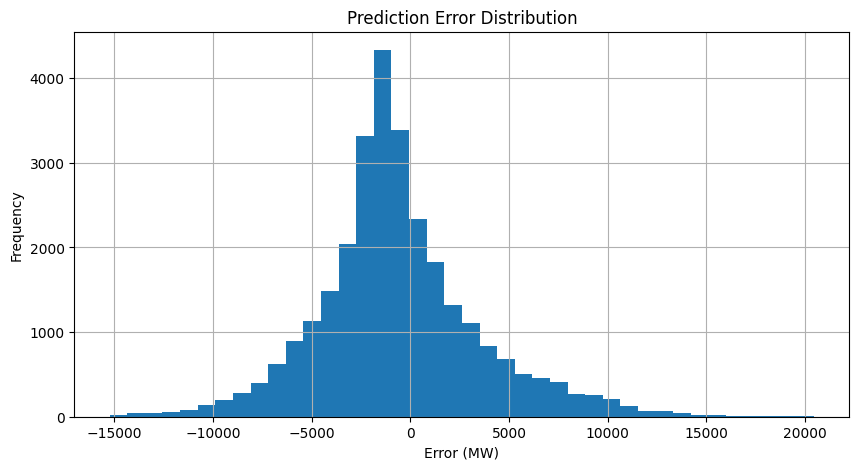


✅ Evaluation Complete!


In [3]:
# ============================================================
# PART 3 - MODEL EVALUATION & SAVE MODEL
# ============================================================

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# ------------------------------------------------------------
# Calculate Metrics
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

accuracy = 100 - mape

print(f"Mean Absolute Error (MAE) : {mae:.2f} MW")
print(f"Root Mean Squared Error   : {rmse:.2f} MW")
print(f"R² Score                  : {r2:.4f}")
print(f"Approximate Accuracy      : {accuracy:.2f}%")

# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

joblib.dump(model, "smart_grid_future.pkl")

print("\n✅ Model saved successfully as:")
print("smart_grid_future.pkl")

# ------------------------------------------------------------
# Feature Importance
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")

print(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

# ------------------------------------------------------------
# Actual vs Predicted
# ------------------------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:300],
    label="Actual",
    linewidth=2
)

plt.plot(
    predictions[:300],
    label="Predicted",
    linewidth=2
)

plt.title("Actual vs Predicted Electricity Demand")

plt.xlabel("Samples")

plt.ylabel("Demand (MW)")

plt.legend()

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Error Distribution
# ------------------------------------------------------------

errors = y_test.values - predictions

plt.figure(figsize=(10,5))

plt.hist(
    errors,
    bins=40
)

plt.title("Prediction Error Distribution")

plt.xlabel("Error (MW)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

print("\n✅ Evaluation Complete!")

In [ ]:
# ============================================================
# SMART ENERGY GRID LOAD & PEAK FORECASTING SYSTEM
# ============================================================

import pandas as pd
import numpy as np

print("="*70)
print("      SMART ENERGY GRID LOAD & PEAK FORECASTING SYSTEM")
print("="*70)

while True:

    print("\nEnter Forecast Date & Time\n")

    day = int(input("Day (1-31): "))
    month = int(input("Month (1-12): "))
    year = int(input("Year: "))
    hour = int(input("Hour (0-23): "))

    try:

        timestamp = pd.Timestamp(
            year=year,
            month=month,
            day=day,
            hour=hour
        )

        weekday = timestamp.weekday()
        dayofyear = timestamp.dayofyear
        weekofyear = int(timestamp.isocalendar().week)
        is_weekend = int(weekday >= 5)

        hour_sin = np.sin(2 * np.pi * hour / 24)
        hour_cos = np.cos(2 * np.pi * hour / 24)

        month_sin = np.sin(2 * np.pi * month / 12)
        month_cos = np.cos(2 * np.pi * month / 12)

        sample = pd.DataFrame({

            "hour": [hour],
            "day": [day],
            "month": [month],
            "year": [year],
            "weekday": [weekday],
            "dayofyear": [dayofyear],
            "weekofyear": [weekofyear],
            "is_weekend": [is_weekend],
            "hour_sin": [hour_sin],
            "hour_cos": [hour_cos],
            "month_sin": [month_sin],
            "month_cos": [month_cos]

        })

        prediction = model.predict(sample)[0]

        print("\n" + "="*70)
        print("FORECAST RESULT")
        print("="*70)

        print(f"Forecast Date      : {timestamp.strftime('%d-%m-%Y')}")
        print(f"Forecast Time      : {timestamp.strftime('%H:%M')}")
        print(f"Weekday            : {timestamp.day_name()}")
        print(f"Predicted Demand   : {prediction:.2f} MW")

        if prediction >= 50000:
            print("Grid Status        : 🔴 HIGH LOAD")
            print("Peak Alert         : YES")
            print("Recommendation     : Increase Power Generation")

        elif prediction >= 40000:
            print("Grid Status        : 🟡 MODERATE LOAD")
            print("Peak Alert         : POSSIBLE")
            print("Recommendation     : Monitor Grid")

        else:
            print("Grid Status        : 🟢 NORMAL LOAD")
            print("Peak Alert         : NO")
            print("Recommendation     : Normal Operation")

        print("="*70)

    except Exception as e:
        print("\nError:", e)

    again = input("\nDo another prediction? (y/n): ")

    if again.lower() != "y":
        break

print("\nThank you for using Smart Energy Grid Forecasting!")

      SMART ENERGY GRID LOAD & PEAK FORECASTING SYSTEM

Enter Forecast Date & Time

Day (1-31): 2
Month (1-12): 8
Year: 2006
Hour (0-23): 17

FORECAST RESULT
Forecast Date      : 02-08-2006
Forecast Time      : 17:00
Weekday            : Wednesday
Predicted Demand   : 59160.26 MW
Grid Status        : 🔴 HIGH LOAD
Peak Alert         : YES
Recommendation     : Increase Power Generation
